# Name: Bennie Kibet
# Project : Syria Tel analysis

## Business Understanding
## Overview:

Syria Tel a telecommunication company operating in Kenya offers a variety of plans to their customers, ranging from international plans, voicemail plans,etc. The company has experienced growth but has a challenge in retaining some customers, as they opt out of their services.


## Problem Statement:

To identify whether arrests made after a Terry Stop, has undergone the procedure of being stopped on suspicious behaviour and frisked, or if other factors play a role in the arrest.

## Metrics:

The effectiveness of Syria Tel predictive models will be evaluated based on the accuracy score. This metric measures the proportion of correctly predicted instances among all instances, providing insight into how well the models can predict arrest occuring after a Terry Stop. A higher accuracy score indicates that the models are more reliable in identifying the arrests made due to Terry Stops.

## Objectives
1. To predict whether how likely a customer could churn
2. Arrest given information about the presence of weapons
3. The time of day of the call

# Data Understanding

In [35]:
# Importing the relevant libraries
import numpy as np
import math 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, classification_report, accuracy_score, confusion_matrix, roc_curve
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn import tree
%matplotlib inline

In [2]:
# Loading the dataset
data = pd.read_csv("Data\Syria_tel.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\benbe\AppData\Local\Temp\ipykernel_18496\2405028064.py:2: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv("Data\Syria_tel.csv")


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
data.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [5]:
# To convert the missing values in the data into nan type
data.replace('-', np.nan, inplace=True)

In [6]:
data.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [7]:
data.duplicated().sum()

0

In [8]:
data["churn"].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

In [9]:
data["total eve minutes"].value_counts()

total eve minutes
169.9    9
167.2    7
180.5    7
201.0    7
161.7    7
        ..
75.3     1
293.9    1
232.8    1
173.2    1
265.9    1
Name: count, Length: 1611, dtype: int64

In [10]:
data['total eve charge'].value_counts()

total eve charge
14.25    11
16.12    11
15.90    10
17.09     9
18.62     9
         ..
7.85      1
8.63      1
26.54     1
6.74      1
22.60     1
Name: count, Length: 1440, dtype: int64

In [11]:
data['total day charge'].value_counts()

total day charge
26.18    8
27.12    8
29.67    8
31.18    7
29.82    7
        ..
13.36    1
34.15    1
43.23    1
41.99    1
30.74    1
Name: count, Length: 1667, dtype: int64

# EDA

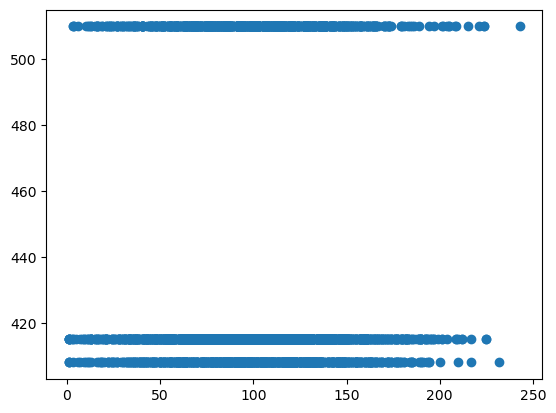

In [12]:
fig, ax = plt.subplots()
ax.scatter(data['account length'], data['area code'])

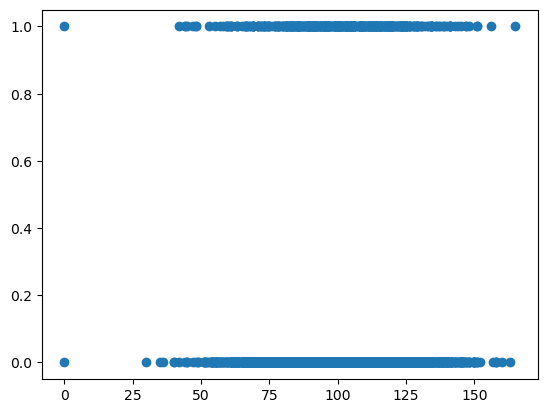

In [13]:
fig, ax = plt.subplots()
ax.scatter(data['total day calls'], data['churn'])

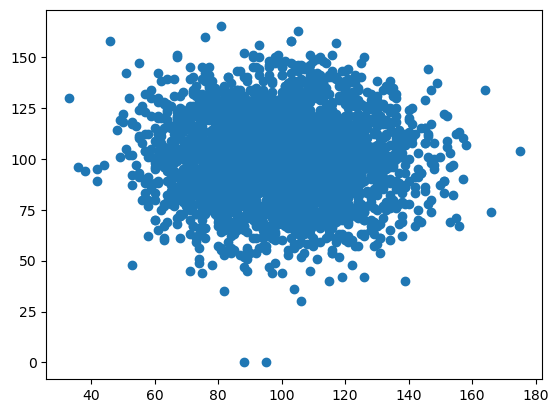

In [14]:
fig, ax = plt.subplots()
ax.scatter(data['total night calls'], data['total day calls'])

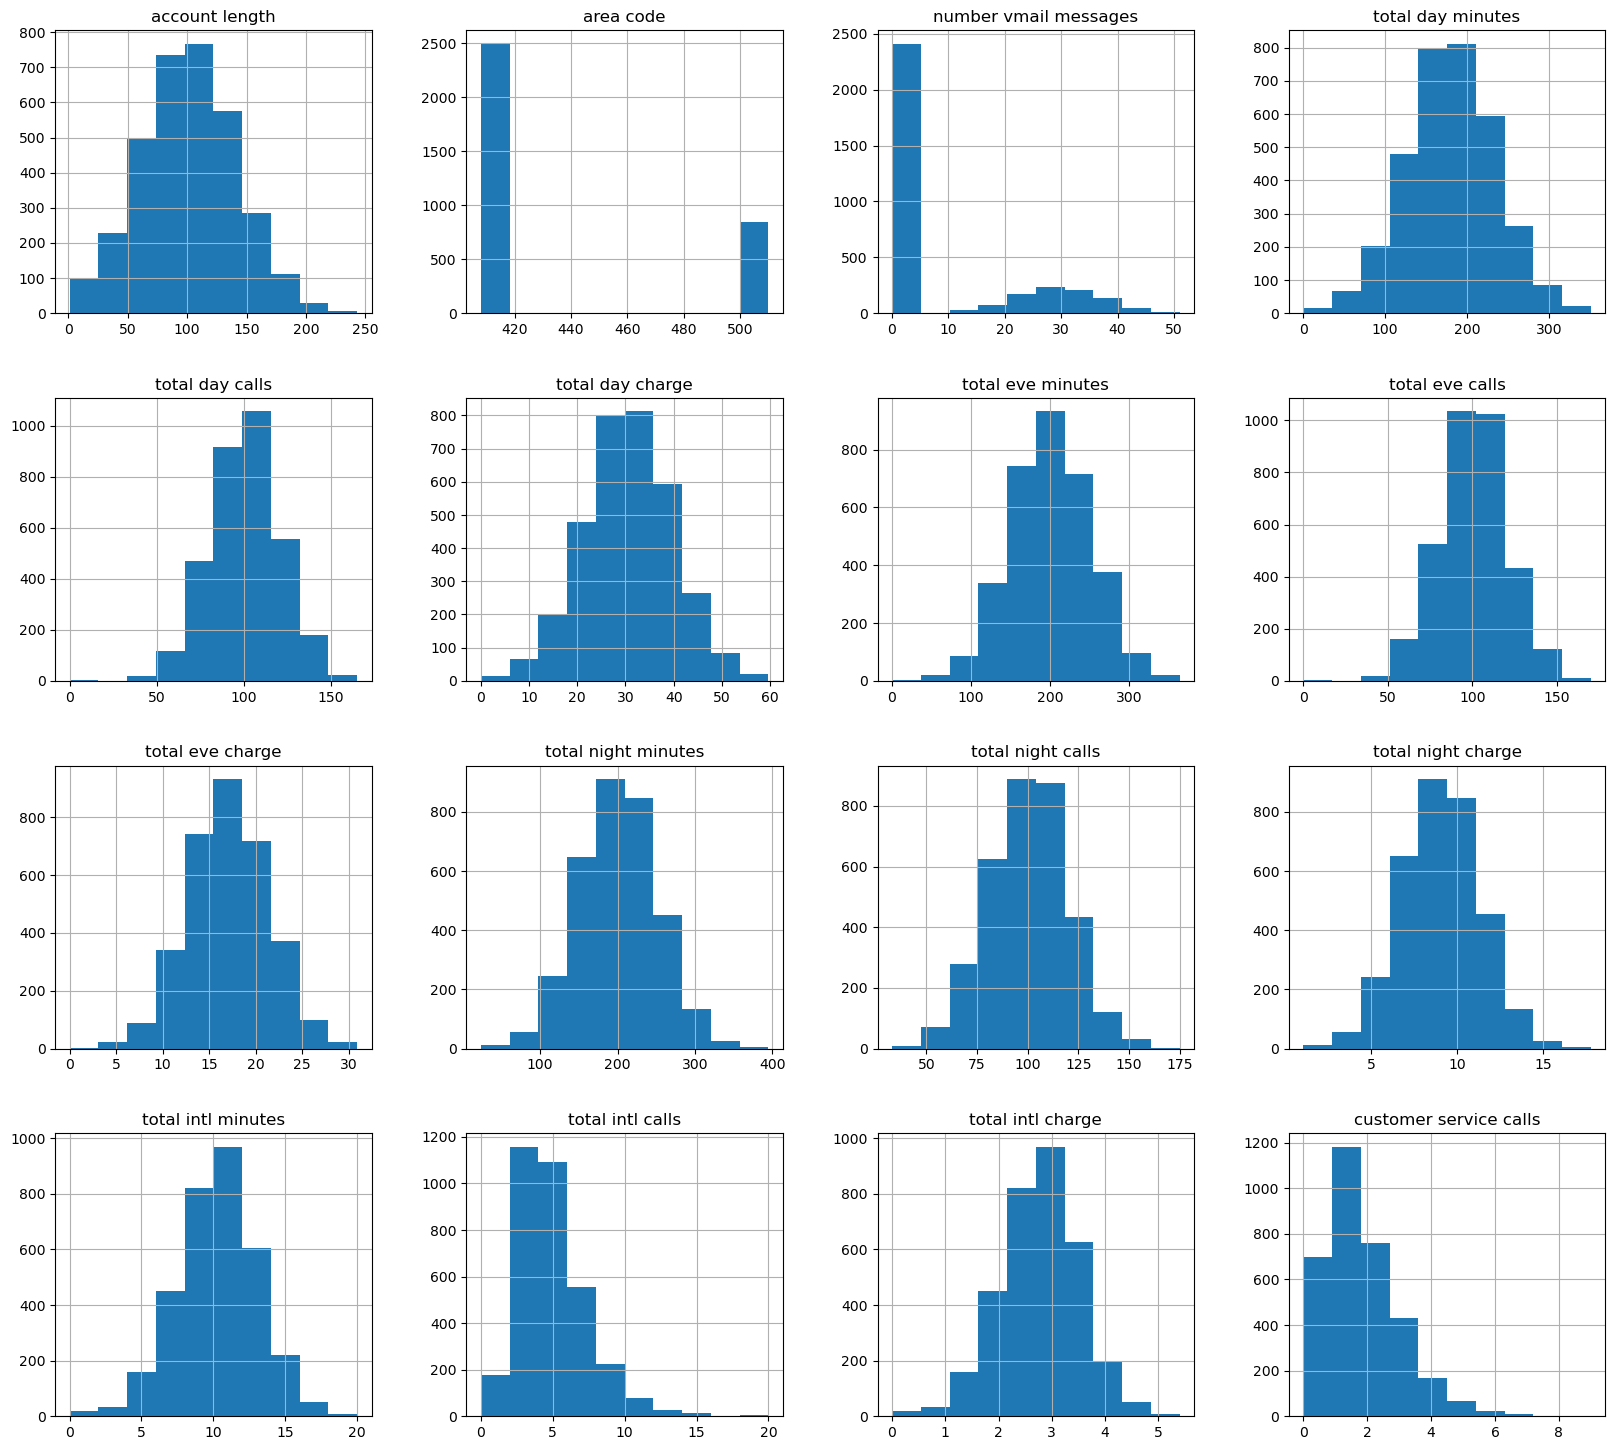

In [15]:
data.hist(figsize = (20,18));

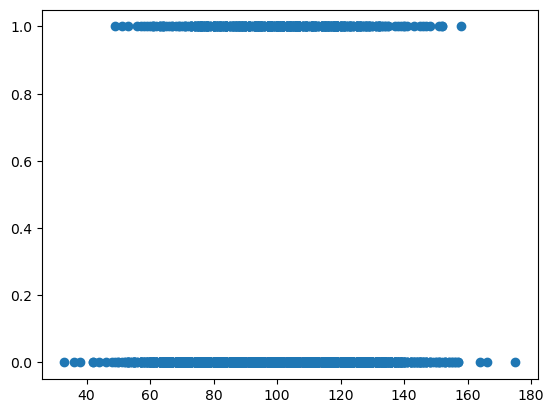

In [16]:
fig, ax = plt.subplots()
ax.scatter(data['total night calls'], data['churn'])

# Data Preparation

In [17]:
data['phone number'].value_counts()

phone number
382-4657    1
348-7071    1
389-6082    1
415-3689    1
379-2503    1
           ..
352-1127    1
368-1288    1
403-5279    1
397-9333    1
400-4344    1
Name: count, Length: 3333, dtype: int64

In [18]:
data["state"].value_counts()

state
WV    106
MN     84
NY     83
AL     80
WI     78
OH     78
OR     78
WY     77
VA     77
CT     74
MI     73
ID     73
VT     73
TX     72
UT     72
IN     71
MD     70
KS     70
NC     68
NJ     68
MT     68
CO     66
NV     66
WA     66
RI     65
MA     65
MS     65
AZ     64
FL     63
MO     63
NM     62
ME     62
ND     62
NE     61
OK     61
DE     61
SC     60
SD     60
KY     59
IL     58
NH     56
AR     55
GA     54
DC     54
HI     53
TN     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [19]:
data.drop(columns=['phone number', 'state'], inplace=True)
data.columns

Index(['account length', 'area code', 'international plan', 'voice mail plan',
       'number vmail messages', 'total day minutes', 'total day calls',
       'total day charge', 'total eve minutes', 'total eve calls',
       'total eve charge', 'total night minutes', 'total night calls',
       'total night charge', 'total intl minutes', 'total intl calls',
       'total intl charge', 'customer service calls', 'churn'],
      dtype='object')

In [20]:
# Splitting the columns based on variable types
categorical_columns = []
numerical_columns = []
for i in data.columns:
    if data[i].dtype == 'O':
        categorical_columns.append(i)
    else:
        numerical_columns.append(i)
        
print(f"Categorical columns:",  categorical_columns) 
print(f"Numerical columns:",  numerical_columns)

Categorical columns: ['international plan', 'voice mail plan']
Numerical columns: ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']


In [21]:
data['international plan'].value_counts()

international plan
no     3010
yes     323
Name: count, dtype: int64

In [22]:
data['voice mail plan'].value_counts()

voice mail plan
no     2411
yes     922
Name: count, dtype: int64

In [23]:
data['account length'].value_counts()

account length
105    43
87     42
101    40
93     40
90     39
       ..
243     1
200     1
232     1
5       1
221     1
Name: count, Length: 212, dtype: int64

In [24]:
# Converting the categorical data to numerical data
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(data[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([data, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded data : \n{df_encoded}")

Encoded data : 
      account length  area code  number vmail messages  total day minutes  \
0                128        415                     25              265.1   
1                107        415                     26              161.6   
2                137        415                      0              243.4   
3                 84        408                      0              299.4   
4                 75        415                      0              166.7   
...              ...        ...                    ...                ...   
3328             192        415                     36              156.2   
3329              68        415                      0              231.1   
3330              28        510                      0              180.8   
3331             184        510                      0              213.8   
3332              74        415                     25              234.4   

      total day calls  total day charge  total eve minutes 

In [25]:
df_encoded.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,...,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,11.01,10.0,3,2.70,1,False,1.0,0.0,0.0,1.0
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,11.45,13.7,3,3.70,1,False,1.0,0.0,0.0,1.0
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,7.32,12.2,5,3.29,0,False,1.0,0.0,1.0,0.0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,8.86,6.6,7,1.78,2,False,0.0,1.0,1.0,0.0
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,8.41,10.1,3,2.73,3,False,0.0,1.0,1.0,0.0


## Checking for Outliers

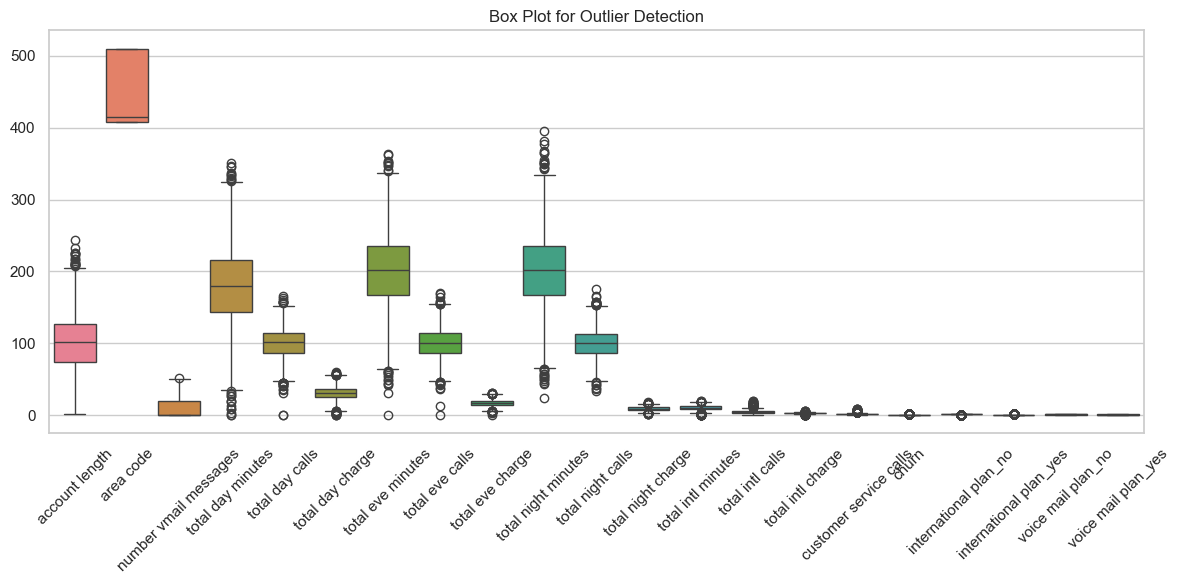

In [26]:
# Set style for better visuals
sns.set(style="whitegrid")

# Plot boxplots for all numeric columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_encoded)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.title("Box Plot for Outlier Detection")
plt.tight_layout()
plt.show()

### Bivariate Analysis

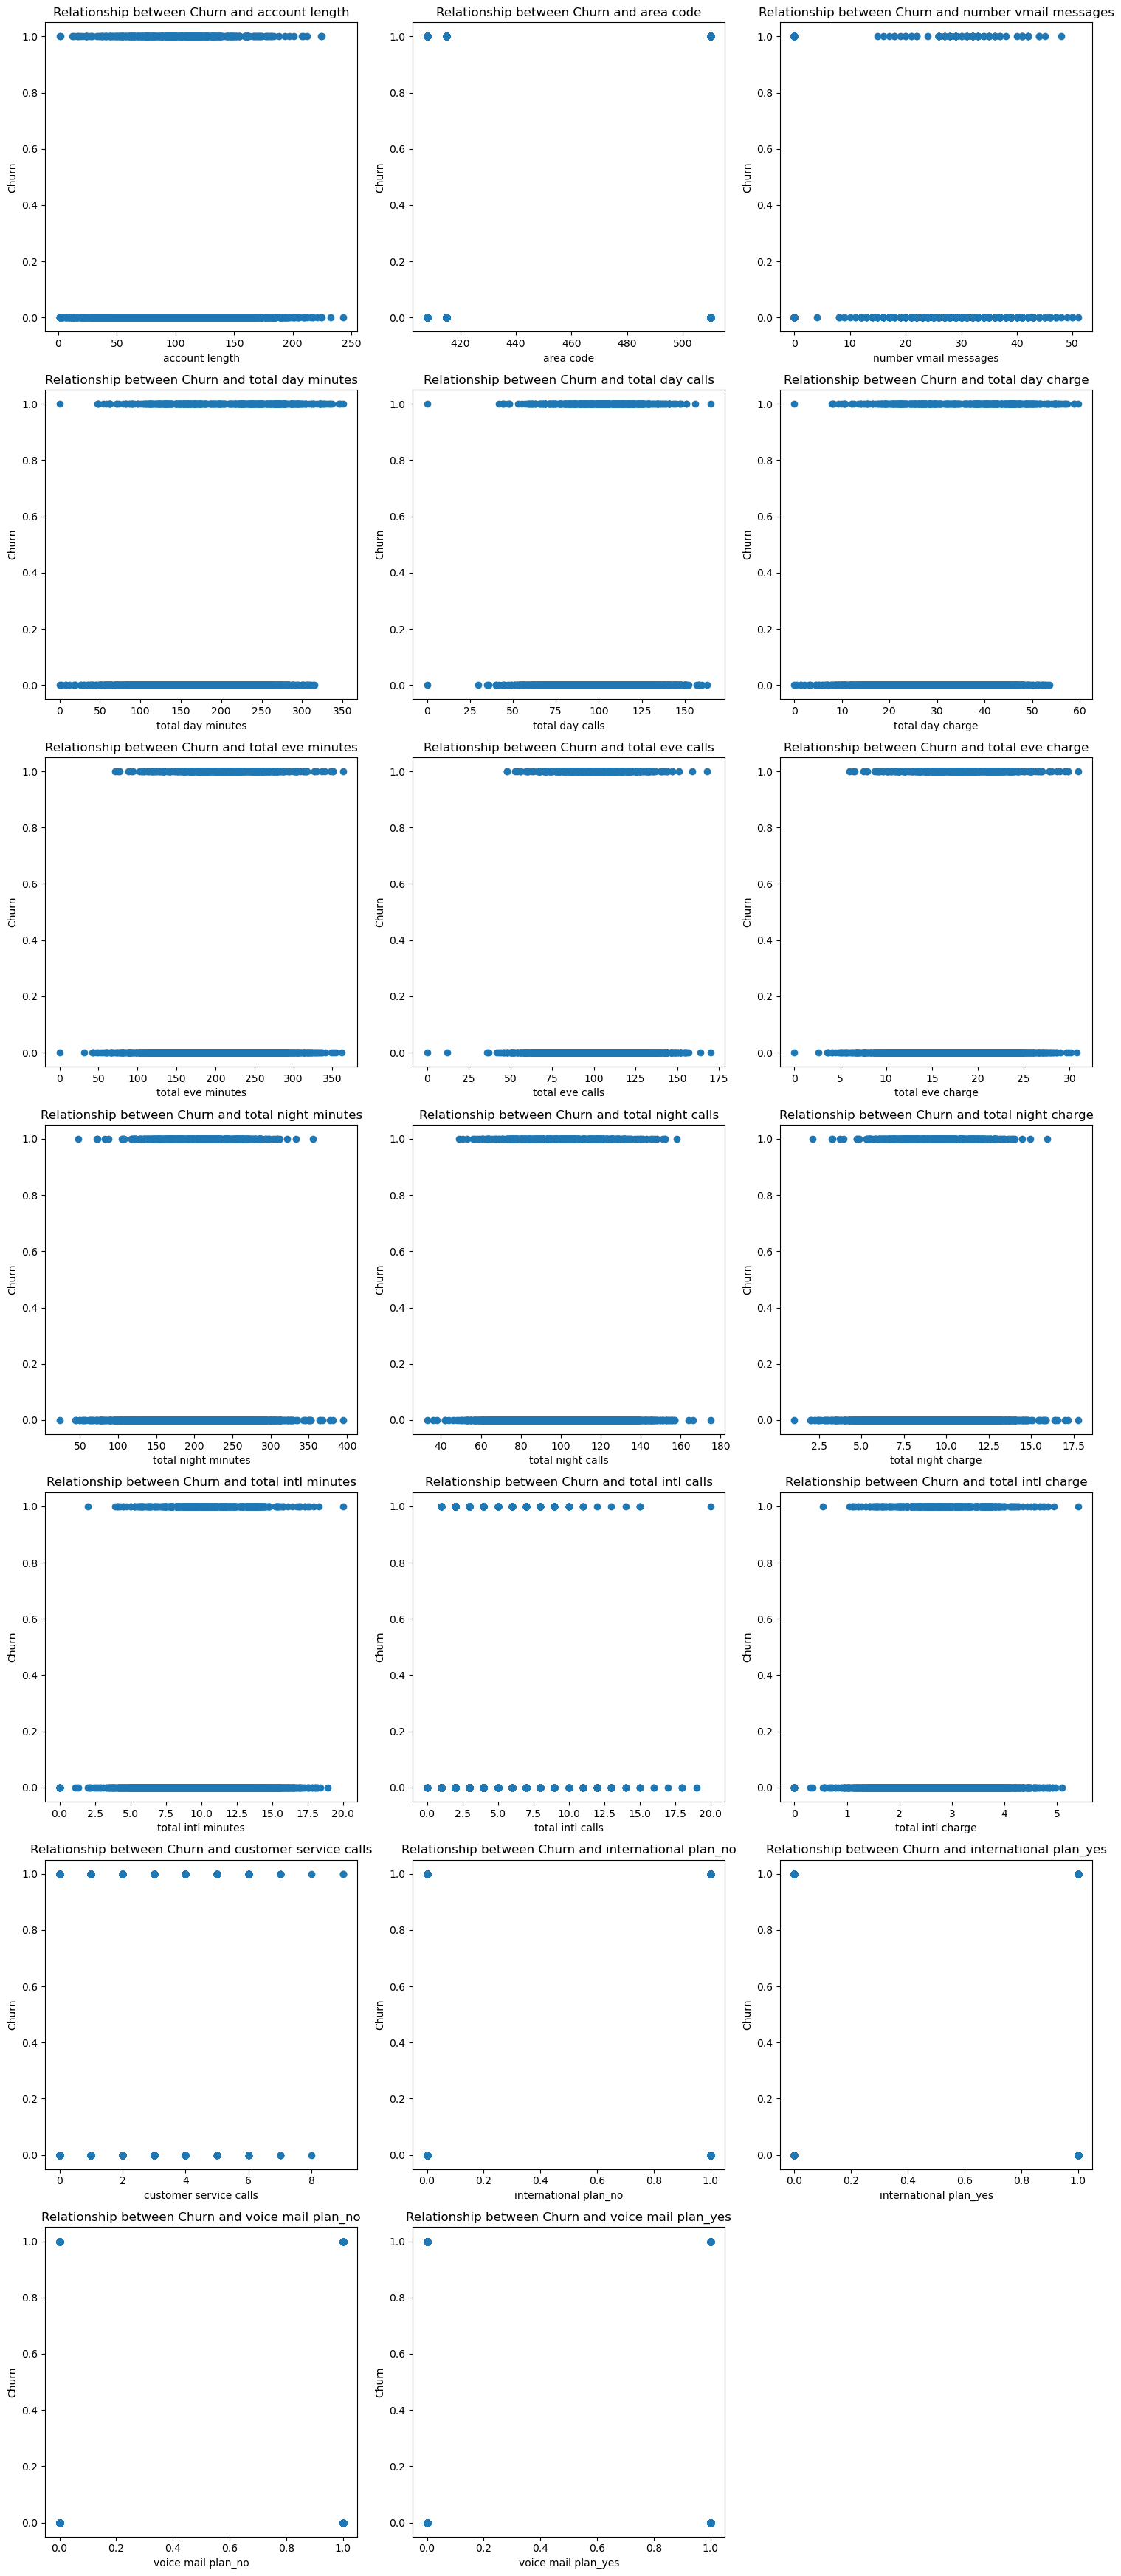

In [37]:
# Examine the relationships between 'churn' and several independent variables through scatter plots
variables = df_encoded.drop('churn', axis=1)
num_rows = math.ceil(len(variables.columns) / 3)  # Calculate the number of rows for the subplots

# Set up a grid of subplots for visualizing relationships
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))
axes = axes.flatten()  # prevents indexing issues

# Plot scatter plots to explore how each independent variable affects 'price'
for i, var in enumerate(variables.columns):
    row = i // 3  # Compute the row index
    col = i % 3   # Compute the column index
    axes[i].scatter(df_encoded[var], df_encoded['churn'])
    axes[i].set_xlabel(var)  # X-axis label
    axes[i].set_ylabel('Churn')  # Y-axis label
    axes[i].set_title(f'Relationship between Churn and {var}')  # Plot title

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
# Adjust layout to avoid overlap of subplots
plt.tight_layout()
plt.show()

### Multivariate Analysis

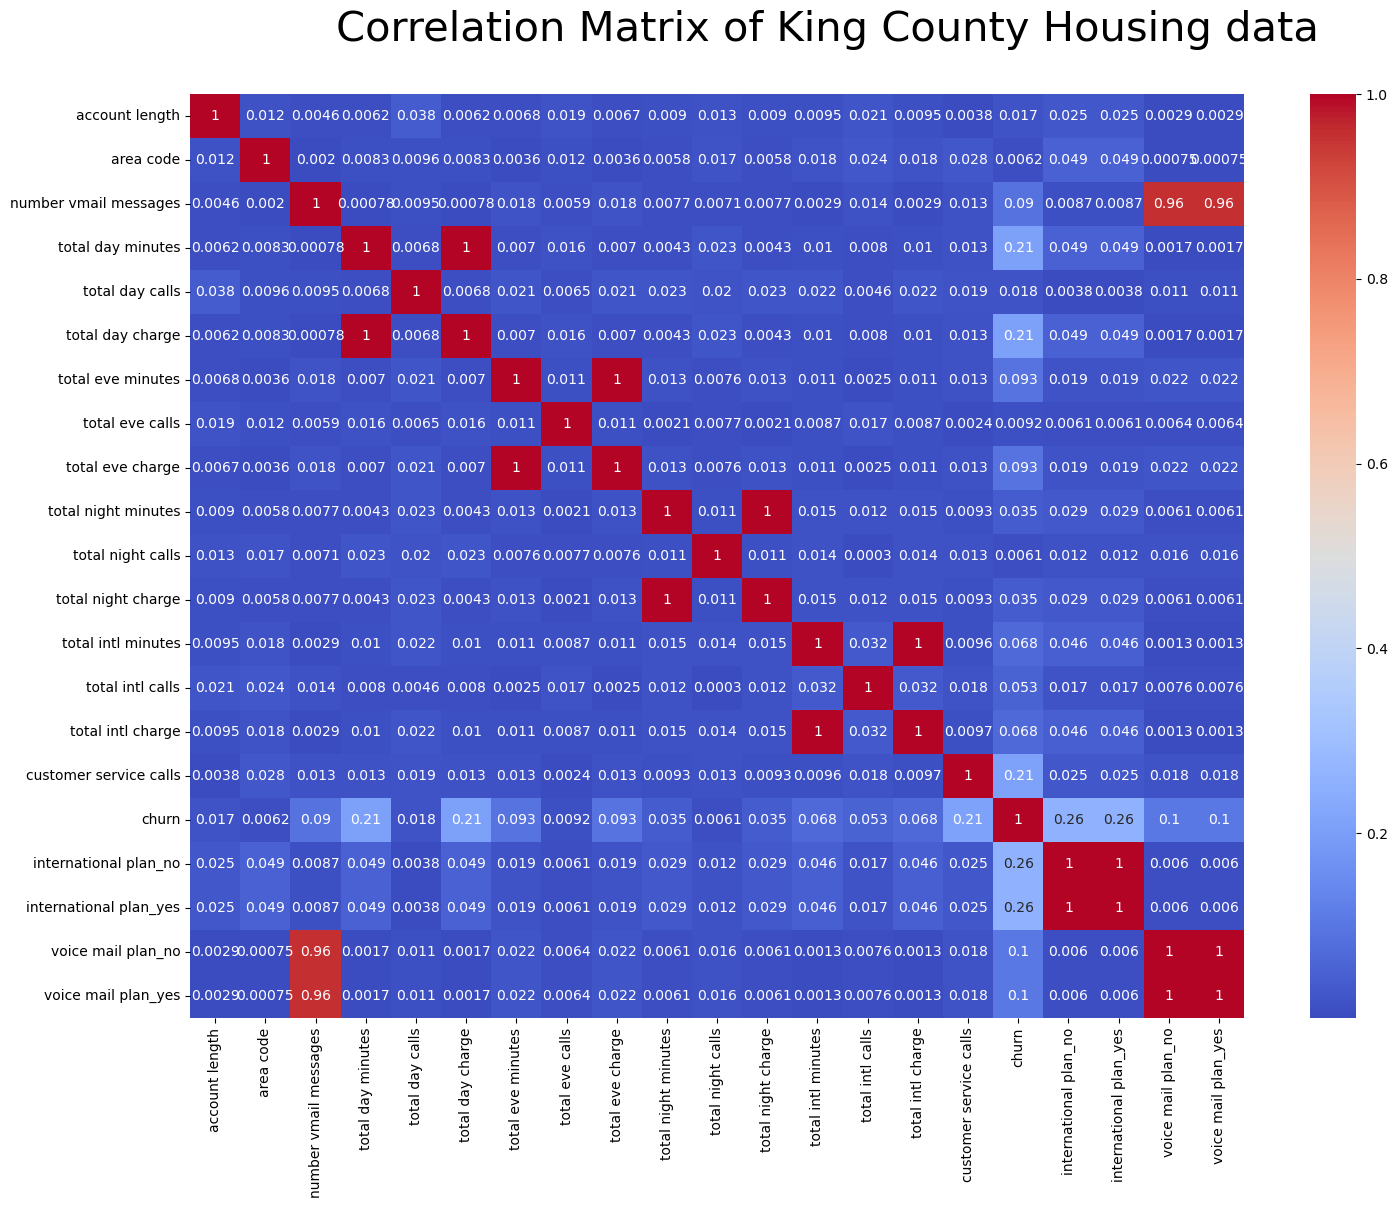

In [26]:
# plot heatmap to show the relationship between various variables
corr = df_encoded.corr().abs()
fig, ax=plt.subplots(figsize=(17,12))
fig.suptitle('Correlation Matrix of King County Housing data', fontsize=30, y=.95, fontname='DejaVu Sans')
heatmap = sns.heatmap(corr, cmap='coolwarm', annot=True)
heatmap;

# Modeling

In [41]:
# Identifying the target and features of the model
y = df_encoded['churn']
X = df_encoded.drop(columns='churn', axis=1)

# Train-test splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [34]:
# Scaling the data
scaler = MinMaxScaler()

# fitting and transforming the train data
X_train_s = scaler.fit_transform(X_train)

# transforming the test data
X_test_s = scaler.transform(X_test)

In [37]:
# Correcting for class imbalance
smote = SMOTE()
#SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

## Baseline model: Logistic Regression

In [ ]:
# defining the model
logreg = LogisticRegression(solver='liblinear')

# fitting the train data
logreg.fit(X_train_smote, y_train_smote)

LogisticRegression(solver='liblinear')

In [46]:
# predicting on unseen data
y_pred = logreg.predict(X_test_s)
print(accuracy_score(y_test, y_pred))

0.7736131934032984


#### Model Evaluation

In [47]:
# a function for checking for metrics 
def evaluate_model_metrics(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate evaluation metrics
    roc_auc_train = roc_auc_score(y_train, y_train_pred)
    roc_auc_test = roc_auc_score(y_test, y_test_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)
    cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm_test).plot()
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)

    # Return results
    results = {
        'roc_auc_train': roc_auc_train,
        'roc_auc_test': roc_auc_test,
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'confusion_matrix_train': cm_display_train
    }
    return results

{'roc_auc_train': 0.7677631578947368,
 'roc_auc_test': 0.7777174896002893,
 'accuracy_train': 0.7677631578947368,
 'accuracy_test': 0.7736131934032984,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1a477d2dd90>}

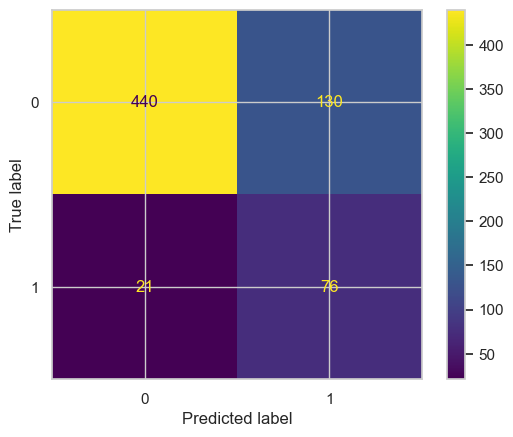

In [48]:
evaluate_model_metrics(logreg, X_train_smote,y_train_smote, X_test_s, y_test)

## Model 2: Logistic Regression with L1 penalty

In [65]:
# defining the model
logreg_1 = LogisticRegression(penalty='l1', solver='liblinear') 

# fitting the train data
logreg_1.fit(X_train_smote, y_train_smote)

LogisticRegression(penalty='l1', solver='liblinear')

In [67]:
# predicting on unseen data
y_pred_1 = logreg_1.predict(X_test_s)
print(accuracy_score(y_test, y_pred))

0.7661169415292354


{'roc_auc_train': 0.7682017543859649,
 'roc_auc_test': 0.7690540784952069,
 'accuracy_train': 0.7682017543859649,
 'accuracy_test': 0.7661169415292354,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1a4799f07d0>}

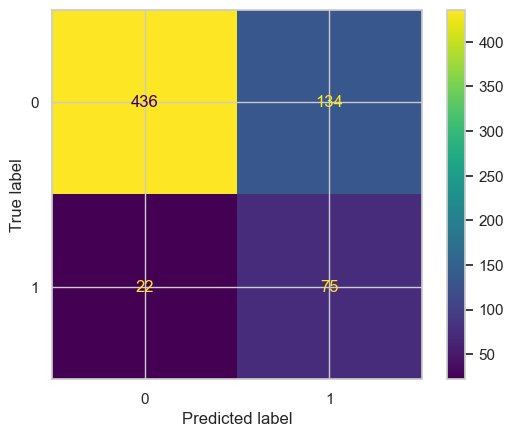

In [68]:
evaluate_model_metrics(logreg_1, X_train_smote,y_train_smote, X_test_s, y_test)

## Model 3: Decision tree classifier

In [86]:
#DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=3)

# Fit the model on the training data
dt_clf.fit(X_train_smote, y_train_smote)

# Predict on the training and testing data
y_train_pred_2= dt_clf.predict(X_train_smote)
y_test_pred_2 = dt_clf.predict(X_test_s)

# Calculate accuracy on the training and testing data
train_accuracy = accuracy_score(y_train_smote, y_train_pred_2)
test_accuracy = accuracy_score(y_test, y_test_pred_2)
print("Train accuracy is ", train_accuracy)
print("Test accuracy is ", test_accuracy)

Train accuracy is  0.8429824561403508
Test accuracy is  0.8755622188905547


[Text(0.5, 0.875, 'total day minutes <= 0.675\ngini = 0.5\nsamples = 4560\nvalue = [2280, 2280]\nclass = False'),
 Text(0.25, 0.625, 'customer service calls <= 0.333\ngini = 0.479\nsamples = 3391\nvalue = [2039, 1352]\nclass = False'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'churn <= 0.5\ngini = 0.408\nsamples = 2744\nvalue = [1962, 782]\nclass = False'),
 Text(0.0625, 0.125, 'gini = 0.353\nsamples = 516\nvalue = [118, 398]\nclass = True'),
 Text(0.1875, 0.125, 'gini = 0.285\nsamples = 2228\nvalue = [1844, 384]\nclass = False'),
 Text(0.375, 0.375, 'total day minutes <= 0.55\ngini = 0.21\nsamples = 647\nvalue = [77, 570]\nclass = True'),
 Text(0.3125, 0.125, 'gini = 0.12\nsamples = 576\nvalue = [37, 539]\nclass = True'),
 Text(0.4375, 0.125, 'gini = 0.492\nsamples = 71\nvalue = [40.0, 31.0]\nclass = False'),
 Text(0.75, 0.625, 'total eve minutes <= 0.456\ngini = 0.327\nsamples = 1169\nvalue = [241, 928]\nclass = True'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'tot

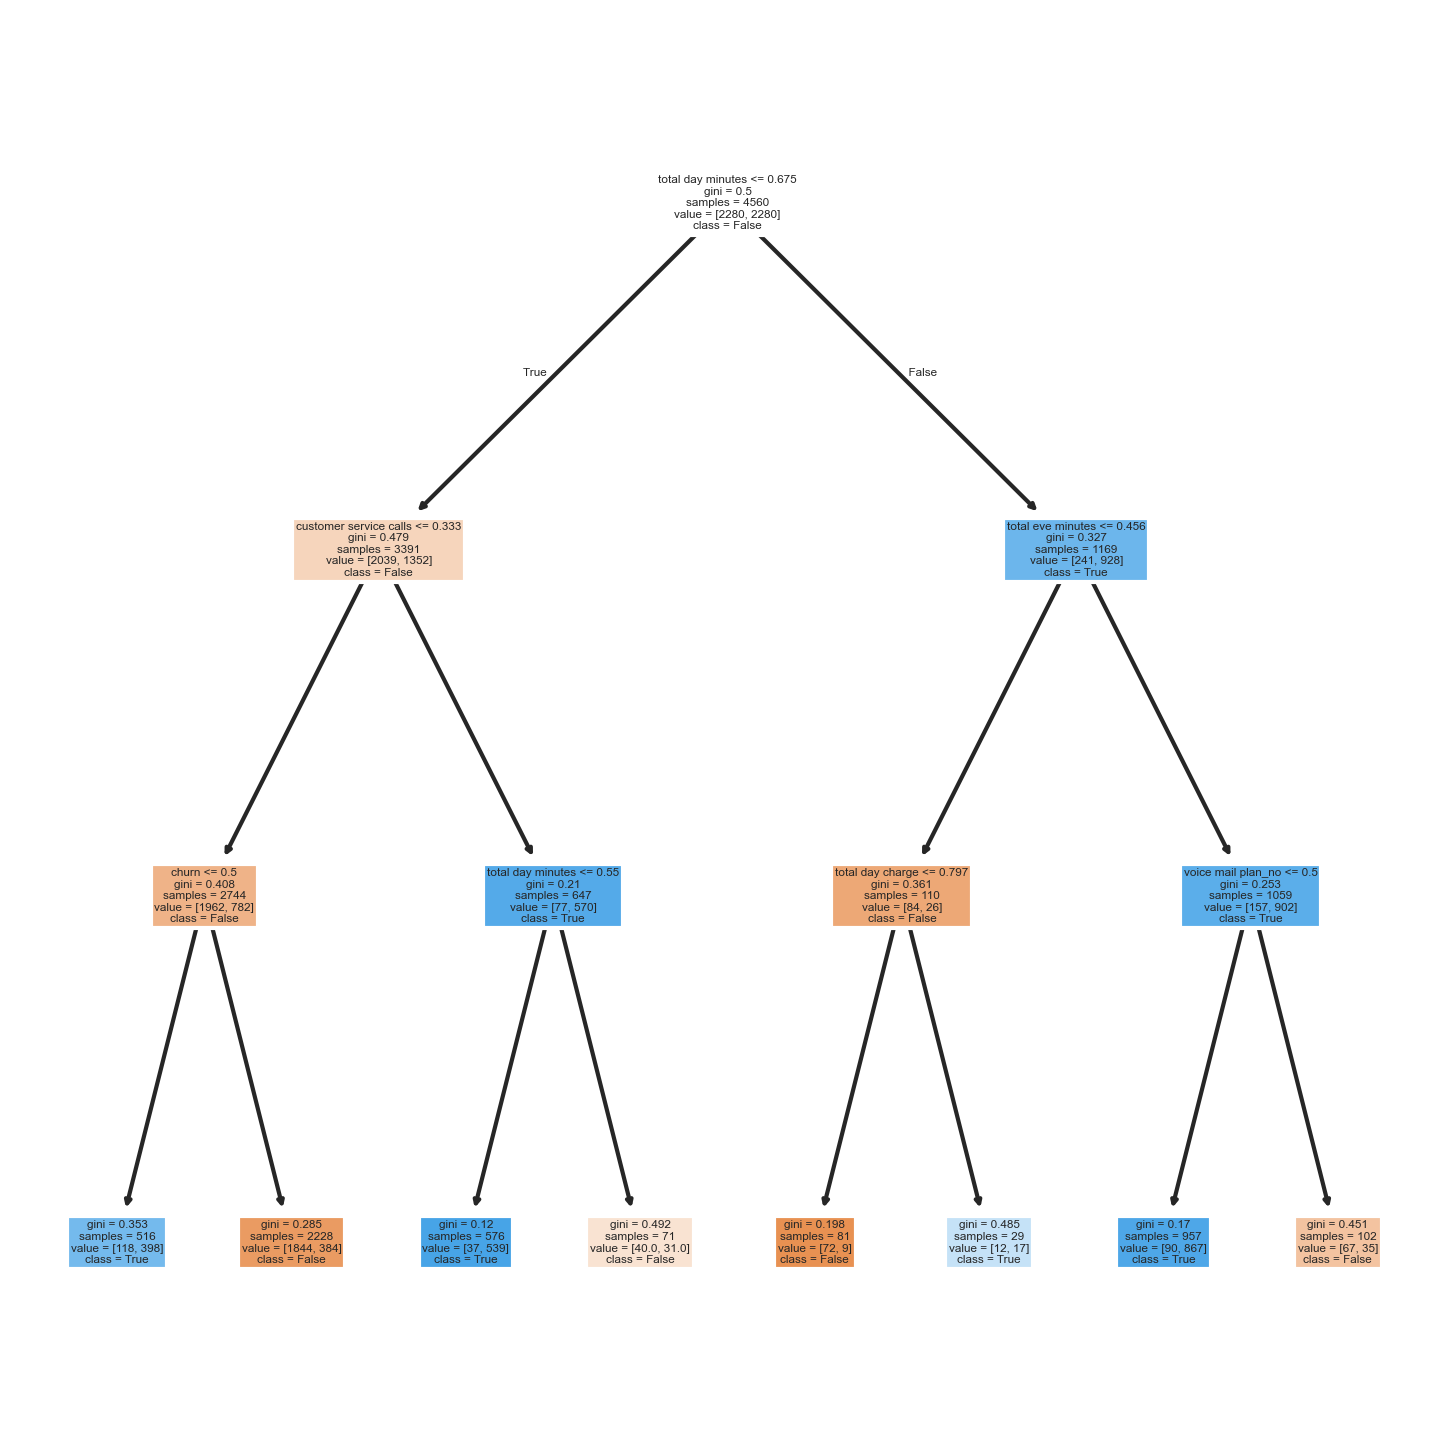

In [87]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (6,6), dpi=300)
tree.plot_tree(dt_clf,
               feature_names= df_encoded.columns,
               class_names= np.unique(y).astype(str),
               filled= True)

{'roc_auc_train': 0.8429824561403509,
 'roc_auc_test': 0.8373666124073068,
 'accuracy_train': 0.8429824561403508,
 'accuracy_test': 0.8755622188905547,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1a47a595af0>}

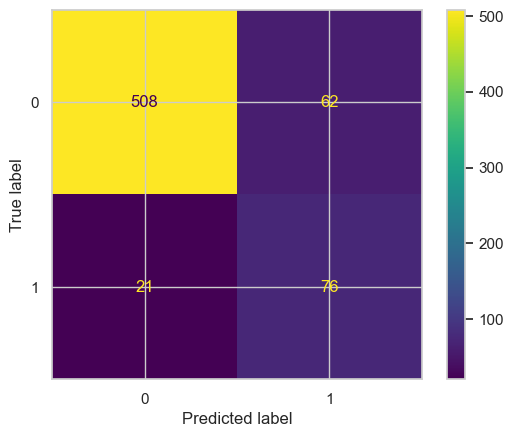

In [90]:
evaluate_model_metrics(dt_clf, X_train_smote,y_train_smote, X_test_s, y_test)

## Model 4: Decision tree with hyperparameter tuning

In [88]:
dt_clf_1 = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)

# Fit the model on the training data
dt_clf_1.fit(X_train_smote, y_train_smote)

# Predict on the training and testing data
y_train_pred_3= dt_clf_1.predict(X_train_smote)
y_test_pred_3 = dt_clf_1.predict(X_test_s)

# Calculate accuracy on the training and testing data
train_accuracy = accuracy_score(y_train_smote, y_train_pred_3)
test_accuracy = accuracy_score(y_test, y_test_pred_3)
print("Train accuracy is ", train_accuracy)
print("Test accuracy is ", test_accuracy)


Train accuracy is  0.893640350877193
Test accuracy is  0.9355322338830585


[Text(0.47836538461538464, 0.9166666666666666, 'total day charge <= 0.675\nentropy = 1.0\nsamples = 4560\nvalue = [2280, 2280]\nclass = False'),
 Text(0.2403846153846154, 0.75, 'customer service calls <= 0.333\nentropy = 0.97\nsamples = 3391\nvalue = [2039, 1352]\nclass = False'),
 Text(0.359375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'international plan_no <= 0.5\nentropy = 0.862\nsamples = 2744\nvalue = [1962, 782]\nclass = False'),
 Text(0.07692307692307693, 0.4166666666666667, 'total day minutes <= 0.636\nentropy = 0.663\nsamples = 2228\nvalue = [1844, 384]\nclass = False'),
 Text(0.038461538461538464, 0.25, 'area code <= 0.068\nentropy = 0.575\nsamples = 2014\nvalue = [1739, 275]\nclass = False'),
 Text(0.019230769230769232, 0.08333333333333333, 'entropy = 0.781\nsamples = 574\nvalue = [441, 133]\nclass = False'),
 Text(0.057692307692307696, 0.08333333333333333, 'entropy = 0.465\nsamples = 1440\nvalue = [1298, 142]\nclass = False'),
 Text(0.115384615384615

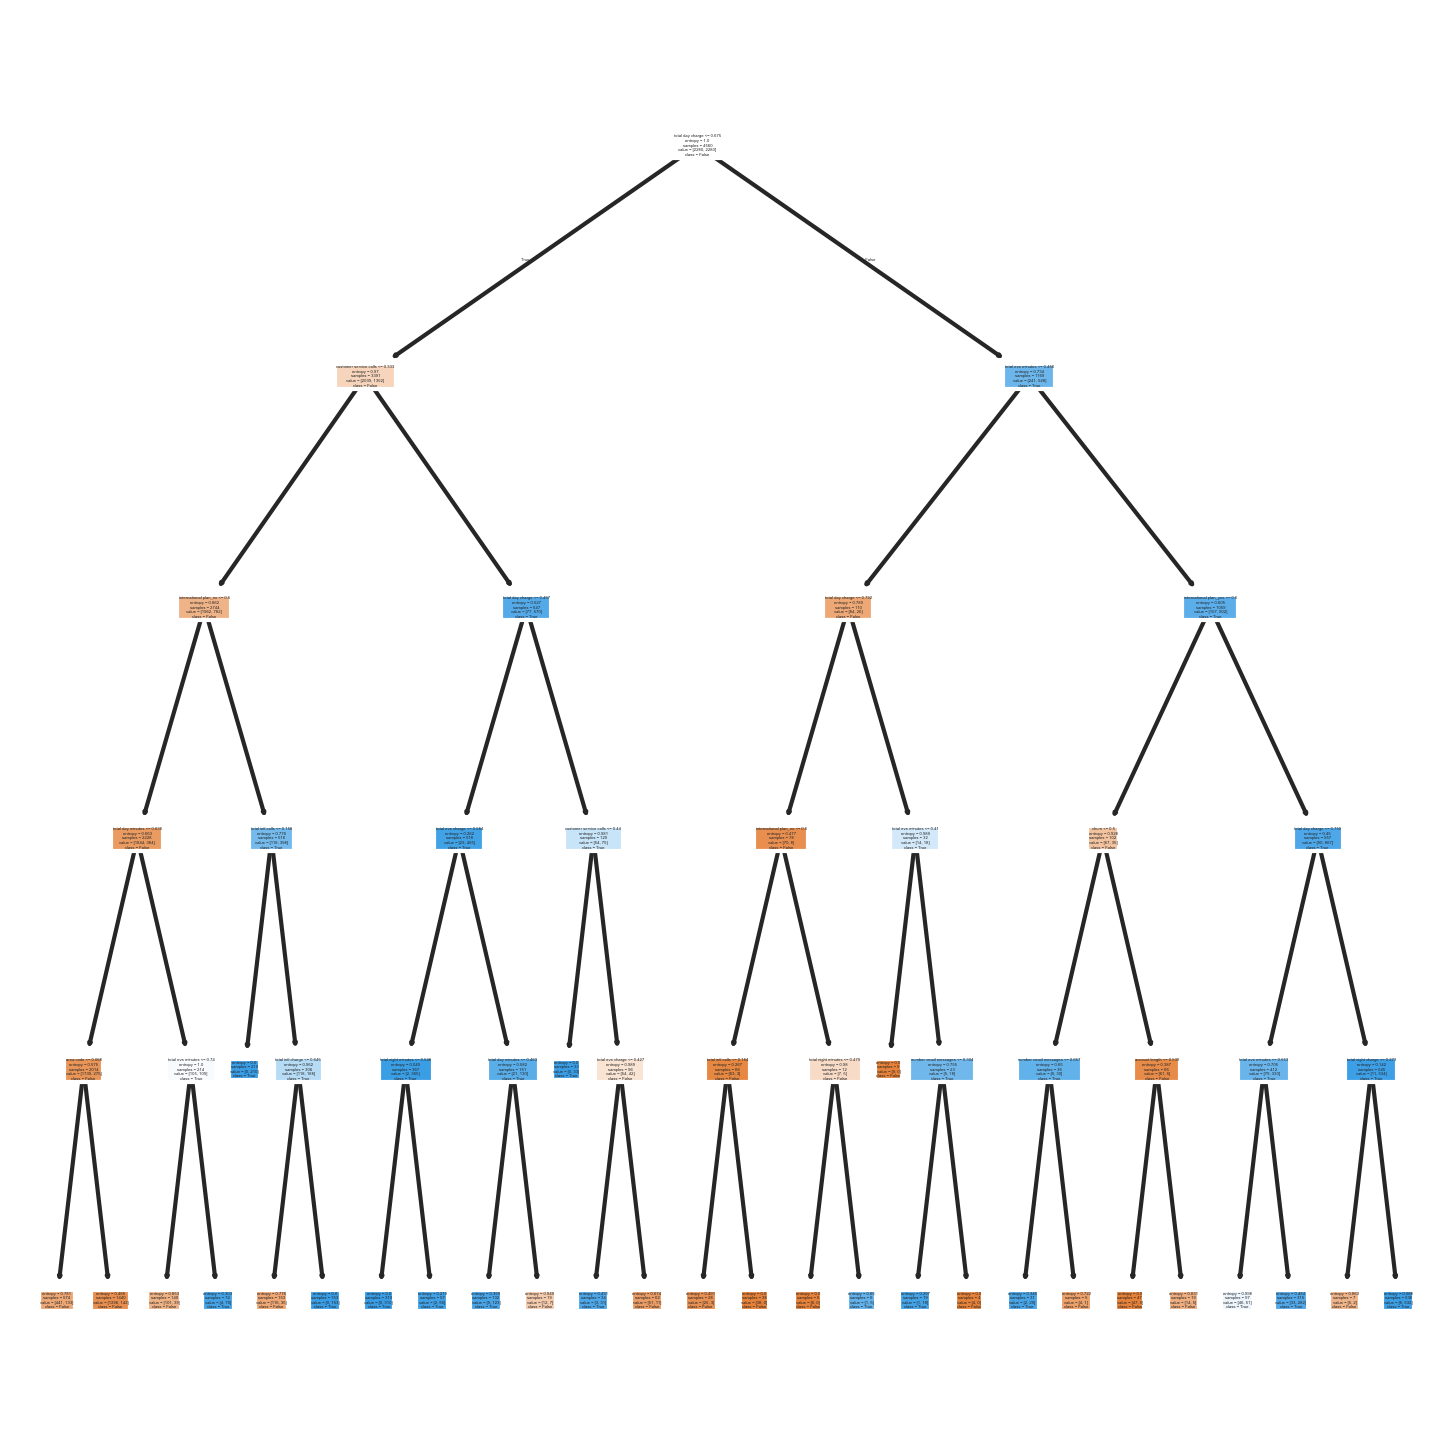

In [89]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (6,6), dpi=300)
tree.plot_tree(dt_clf_1,
               feature_names= df_encoded.columns,
               class_names= np.unique(y).astype(str),
               filled= True)

{'roc_auc_train': 0.893640350877193,
 'roc_auc_test': 0.8852866702839572,
 'accuracy_train': 0.893640350877193,
 'accuracy_test': 0.9355322338830585,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1a47e79f620>}

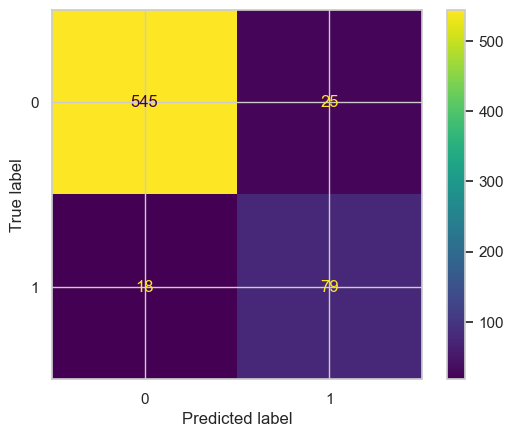

In [91]:
evaluate_model_metrics(dt_clf_1, X_train_smote,y_train_smote, X_test_s, y_test)

# Evaluation

c:\Users\benbe\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\benbe\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\benbe\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


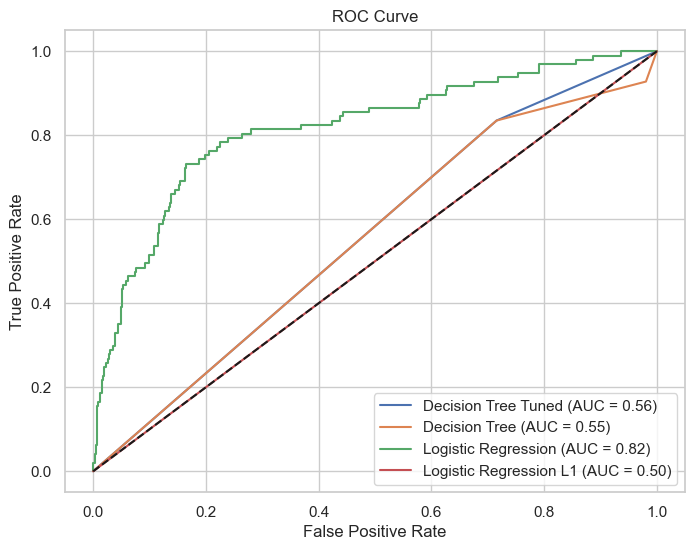

In [95]:
models = [dt_clf, dt_clf_1, logreg, logreg_1]
labels = ['Decision Tree Tuned', 'Decision Tree', 
          'Logistic Regression', 'Logistic Regression L1']

plt.figure(figsize=(8, 6))

for model, label in zip(models, labels):
    # Use predict_proba if available, otherwise decision_function
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Conclusion
